## Part 1
Selected datasets for analysis based on file size:
- Small: REQUESTS_FOR_COMMENT.csv
- Medium: REQUESTS_FOR_PERMISSIONS.csv
- Large: USERS.csv

### Task A (network construction)

In [169]:
import collections
import json

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend

In [135]:
df_users = pd.read_csv('USERS.csv')
df_permissions = pd.read_csv('REQUESTS_FOR_PERMISSIONS.csv')
df_comment = pd.read_csv('REQUESTS_FOR_COMMENT.csv')

In [136]:
def build_editor_network(df):
    G = nx.Graph()
    grouped = df.groupby(['page_name', 'thread_subject'])['username'].apply(set)
    
    for (page, thread), users in grouped.items():
        users = list(users)
        for i in range(len(users)):
            for j in range(i +1, len(users)):
                u1, u2 = users[i], users[j]
                if G.has_edge(u1, u2):
                    G[u1][u2]['weight'] += 1
                else:
                    G.add_edge(u1, u2, weight = 1)
    return G

In [137]:
G_small = build_editor_network(df_comment)
G_medium = build_editor_network(df_permissions)
G_large = build_editor_network(df_users)

graphs = {
    'Small (Requests for Comment)': G_small,
    'Medium (Requests for Permissions)': G_medium,
    'Large (Users)': G_large
}

In [138]:
for name, G in graphs.items():
    print(f"___ {name}___")
    print(f"Nodes:{G.number_of_nodes()}")
    print(f"Edges:{G.number_of_edges()}")
    print(f"Connected components: {nx.number_connected_components(G)}")
    largest_cc = max(nx.connected_components(G), key = len)
    print(f"Largest component size: {len(largest_cc)}")
    print()

___ Small (Requests for Comment)___
Nodes:837
Edges:27569
Connected components: 3
Largest component size: 833

___ Medium (Requests for Permissions)___
Nodes:1727
Edges:27565
Connected components: 3
Largest component size: 1723

___ Large (Users)___
Nodes:8390
Edges:24692
Connected components: 265
Largest component size: 7767



#### Brief Summary
- Nodes represent Wikidata editorss(usernames), and undirected weighted edges connect two users who have commented in the same thread within the same page, representing a direct conversational interaction.
- The network is represented as a NetworkX undirected graph using a adjacency dictionary structure, while the additional information like interaction frequency (weight) or thread metadata can be stored as edge attributes or maintained in a seperate pandas DataFrame lookup table.
- The process invovles grouping data by page and thread to extract unique usernames, generating all possible pairs within each group, and either creating or incrementing edge weights to reflect the total number f distinct threads where bith users co-participated.

### Task 2 (network metrics)

In [139]:
components = {}
for name, G in graphs.items():
    largest_cc = max(nx.connected_components(G), key = len)
    components[name] = G.subgraph(largest_cc).copy()
    print(f"{name}: {components[name].number_of_nodes()} nodes, "
          f"{components[name].number_of_edges()} edges")

Small (Requests for Comment): 833 nodes, 27567 edges
Medium (Requests for Permissions): 1723 nodes, 27563 edges
Large (Users): 7767 nodes, 24219 edges


In [140]:
def compute_basic_metrics(G, name):
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    degree_sequece = [d for _, d in G.degree()]
    avg_degree = sum(degree_sequece) / n_nodes

    degrees = dict(G.degree())
    max_degree_node = max(degrees, key=degrees.get)
    max_degree = degrees[max_degree_node]

    density = nx.density(G)

    avg_clustering = nx.average_clustering(G)

    avg_path_length = nx.average_shortest_path_length(G)

    diameter = nx.diameter(G)

    print(f"--- {name} ---")
    print(f"Nodes: {n_nodes}")
    print(f"Edges: {n_edges}")
    print(f"Density: {density: .4f}")
    print(f"Average degree: {avg_degree: .2f}")
    print(f"Max degree: {max_degree} (node: {max_degree_node})")
    print(f"Average clustering coefficient: {avg_clustering:.4f}")
    print(f"Average path lentgh: {avg_path_length: .4f}")
    print(f"Diameter: {diameter}")
    print()

    return{
        'nodes': n_nodes, 'edges': n_edges, 'density': density,
        'avg_degree': avg_degree, 'max_degree': max_degree,
        'avg_clustering': avg_clustering,
        'avg_path_length': avg_path_length, 'diameter': diameter
    }

In [141]:
metrics = {}
for name, G in components.items():
    metrics[name] = compute_basic_metrics(G, name)

--- Small (Requests for Comment) ---
Nodes: 833
Edges: 27567
Density:  0.0796
Average degree:  66.19
Max degree: 458 (node: Rschen7754)
Average clustering coefficient: 0.8334
Average path lentgh:  2.0867
Diameter: 4

--- Medium (Requests for Permissions) ---
Nodes: 1723
Edges: 27563
Density:  0.0186
Average degree:  31.99
Max degree: 789 (node: Ymblanter)
Average clustering coefficient: 0.6897
Average path lentgh:  2.4713
Diameter: 5

--- Large (Users) ---
Nodes: 7767
Edges: 24219
Density:  0.0008
Average degree:  6.24
Max degree: 649 (node: Infovarius)
Average clustering coefficient: 0.2441
Average path lentgh:  3.6356
Diameter: 10



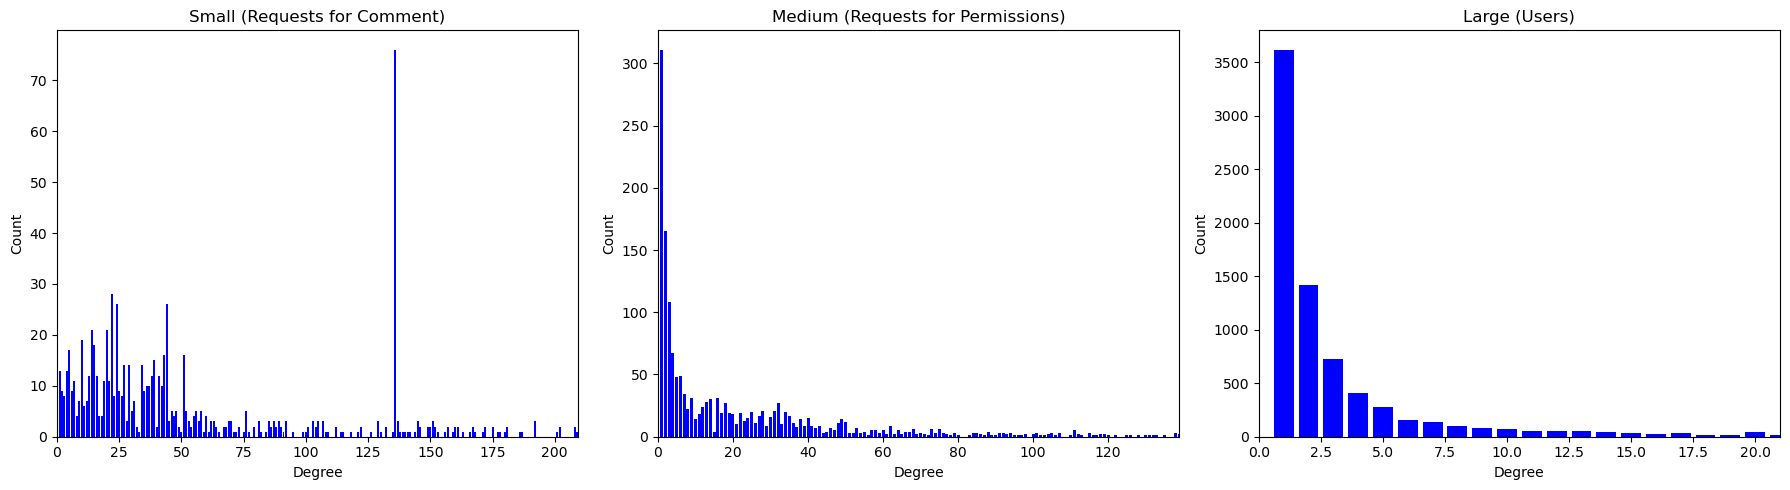

In [142]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, G) in zip(axes, components.items()):
    degree_sequence = [d for _, d in G.degree()]
    degree_count = collections.Counter(degree_sequence)
    deg, cnt = zip(*degree_count.items())

    ax.bar(deg, cnt, color='b')
    ax.set_title(f"{name}")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Count")

    upper = np.percentile(degree_sequence, 95)
    ax.set_xlim(0, upper)
    
plt.tight_layout()
plt.show()

In [143]:
def build_eros_renyi(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    p = (2 * m) / (n *(n - 1))
    return nx.erdos_renyi_graph(n,p)

def build_watts_strogatz(G):
    n = G.number_of_nodes()
    avg_deg = sum(d for _, d in G.degree()) / n
    k = int(round(avg_deg))
    if k % 2 != 0:
        k += 1
    return nx.watts_strogatz_graph(n=n, k=k, p=0.3)

def build_barabasi_albert(G):
    n = G.number_of_nodes()
    avg_deg = sum(d for _, d in G.degree()) / n
    m = max(1, int(round(avg_deg / 2)))
    return nx.barabasi_albert_graph(n=n, m=m)


In [144]:
random_graphs = {}
for name, G in components.items():
    n = G.number_of_nodes()
    avg_deg = sum(d for _, d in G.degree()) / n

    er = build_eros_renyi(G)
    ws = build_watts_strogatz(G)
    ba = build_barabasi_albert(G)

    random_graphs[name] = {'ER': er, 'WS': ws, 'BA': ba}

    print(f"--- {name} ---")
    print(f"Real: n={n}, avg_degree={avg_deg: .2f}")
    print(f"ER edges: {er.number_of_edges()}")
    print(f"WS edges: {ws.number_of_edges()}")
    print(f"BA edges: {ba.number_of_edges()}")
    print()

--- Small (Requests for Comment) ---
Real: n=833, avg_degree= 66.19
ER edges: 27573
WS edges: 27489
BA edges: 26400

--- Medium (Requests for Permissions) ---
Real: n=1723, avg_degree= 31.99
ER edges: 27586
WS edges: 27568
BA edges: 27312

--- Large (Users) ---
Real: n=7767, avg_degree= 6.24
ER edges: 24114
WS edges: 23301
BA edges: 23292



In [145]:
def compute_metrics(G):
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        
    n = G.number_of_nodes()
    degree_seq = [d for _, d in G.degree()]

    return{
        'Nodes': n,
        'Edge': G.number_of_edges(),
        'Avg Degree': sum(degree_seq) / n,
        'Avg Clustering': nx.average_clustering(G),
        'Avg Path Length': nx.average_shortest_path_length(G)
    }

for name, G in components.items():
    print(f"--- {name} ---")
    
    real = compute_metrics(G)

    er = compute_metrics(random_graphs[name]['ER'])
    ws = compute_metrics(random_graphs[name]['WS'])
    ba = compute_metrics(random_graphs[name]['BA'])

    comparison = pd.DataFrame({
        'Real': real,
        'Erdos-Renyi': er,
        'Watts-Strogatz': ws,
        'Barabasi-Albert': ba
    })
    print(comparison.to_string())
    print()

--- Small (Requests for Comment) ---
                         Real   Erdos-Renyi  Watts-Strogatz  Barabasi-Albert
Nodes              833.000000    833.000000      833.000000       833.000000
Edge             27567.000000  27573.000000    27489.000000     26400.000000
Avg Degree          66.187275     66.201681       66.000000        63.385354
Avg Clustering       0.833428      0.079680        0.284020         0.150224
Avg Path Length      2.086738      1.925184        1.966438         1.945846

--- Medium (Requests for Permissions) ---
                         Real   Erdos-Renyi  Watts-Strogatz  Barabasi-Albert
Nodes             1723.000000   1723.000000     1723.000000      1723.000000
Edge             27563.000000  27586.000000    27568.000000     27312.000000
Avg Degree          31.994196     32.020894       32.000000        31.702844
Avg Clustering       0.689669      0.018574        0.257341         0.059214
Avg Path Length      2.471272      2.522267        2.689294         2.444

In [146]:
def node_level_descriptors(graph):

    degrees = [d for _, d in graph.degree()]
    clustering_coeffs = [d for _, d in nx.clustering(graph).items()]
    return {
        'degree': degrees,
        'clustering_coeffs': clustering_coeffs
    }

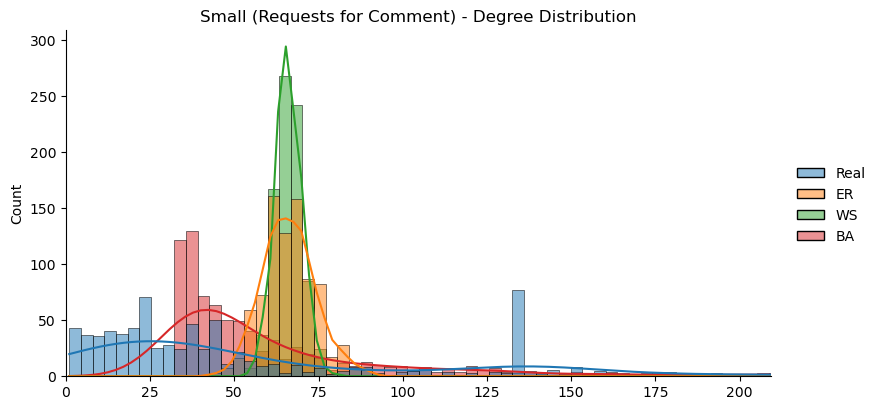

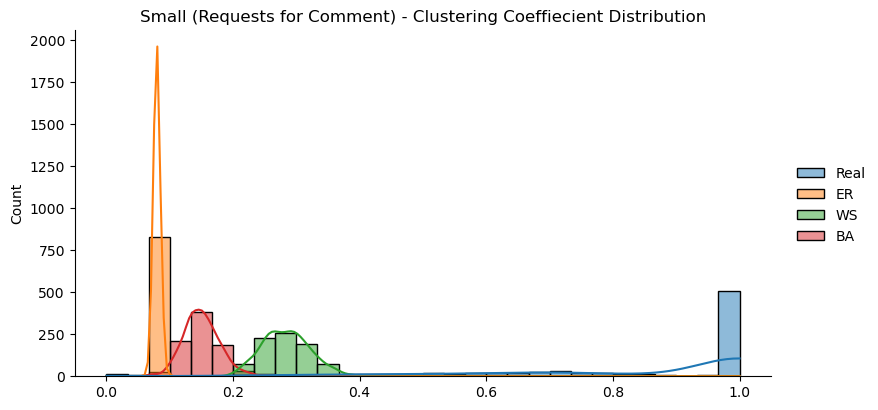

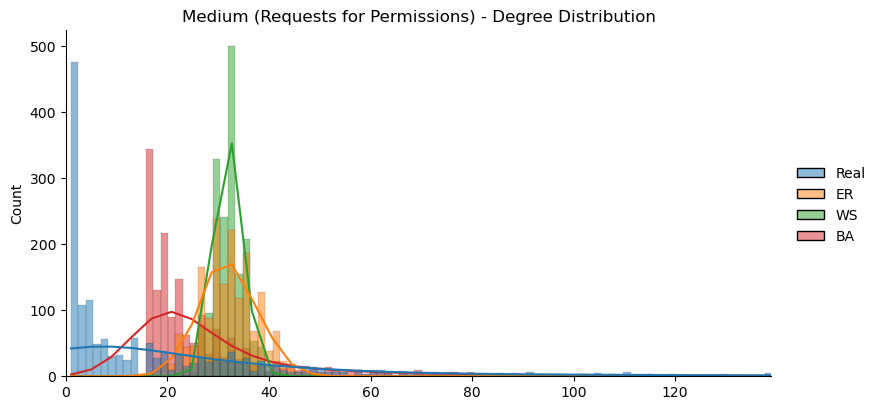

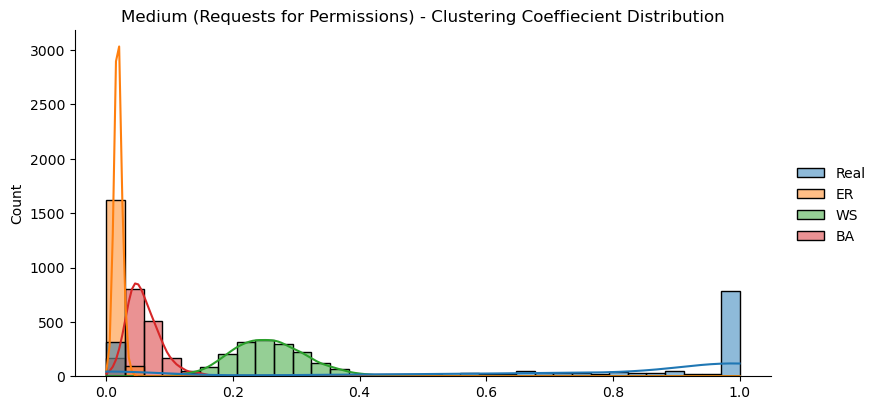

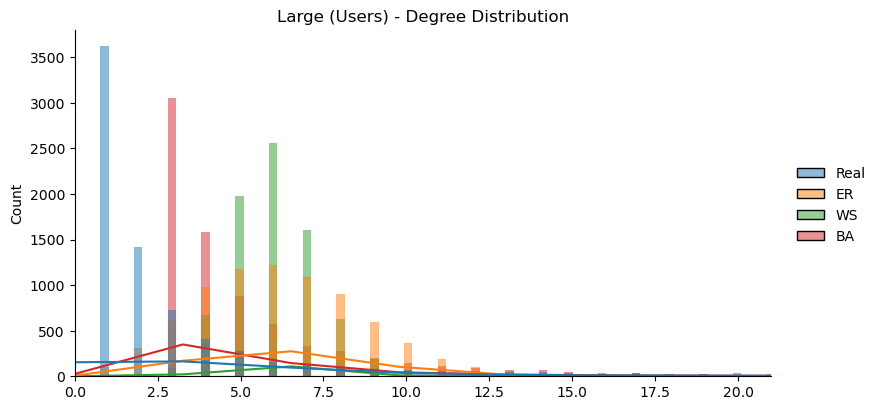

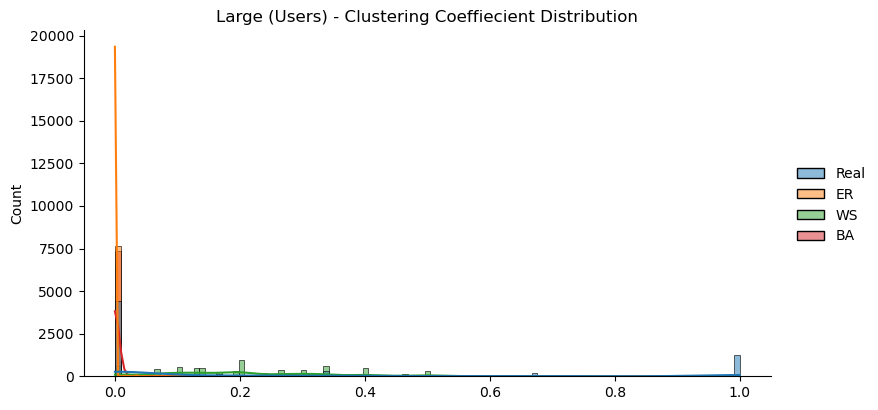

In [147]:
for name, G in components.items():
    real_desc = node_level_descriptors(G)
    er_desc = node_level_descriptors(random_graphs[name]['ER'])
    ws_desc = node_level_descriptors(random_graphs[name]['WS'])
    ba_desc = node_level_descriptors(random_graphs[name]['BA'])

    g = sns.displot(
        {"Real": real_desc["degree"],
         "ER": er_desc["degree"],
         "WS": ws_desc["degree"],
         "BA": ba_desc["degree"]},
         height=4,aspect=2, kde=True
    )
    
    upper = np.percentile(real_desc["degree"], 95)
    g.ax.set_xlim(0, upper)
    plt.title(f"{name} - Degree Distribution")
    plt.show()

    sns.displot(
        {"Real": real_desc["clustering_coeffs"],
         "ER": er_desc["clustering_coeffs"],
         "WS": ws_desc["clustering_coeffs"],
         "BA": ba_desc["clustering_coeffs"]},
         height=4, aspect=2,kde=True
    )
    plt.title(f"{name} - Clustering Coeffiecient Distribution")
    plt.show()

#### Brief Summary
- The three Wikidata editor networks are sparse, scale-free graphs characterized by high clustering coefficients and short average lengths, indicating highly structured, tightly-knit communities where mmost editors are connected via a few steps. The degree distributions are right-skewed and heavy-tailed, showing that a small number of highly active hubs maintain tje majority of connections while most editors have relatively few.

- The Wijidata editor networks echibit significantly hogher lustering than Erdős-Rényi, Watts-Strogatz, and Barabási-Albert models while maintainingcomparable short path lengths and a heavy-tailed degree distribution. These findings confirm the networks possess both small-world and scale-free properties that arise from structured social interactions rather than high-density discussion groups and prominent hub nodes.

- The network structure indicates that editors from tight-knit, topic-drivem commuities where highly active hub editors facilitate communication by bridging otherwise separate groups, creating a small-world effect. Futhermore, interaction patterns vary significantly by context, ranging from dense, public discussions in request forums to more fragmented, private conversations on individual user talk pages.

### Task C (epidemic models)

In [170]:
import random

def check_distance(G, name, seed=42):
    random.seed(seed)
    nodes = list(G.nodes())
    editor1, editor2 = random.sample(nodes, 2)

    try:
        path = nx.shortest_path(G, editor1, editor2)
        distance = nx.shortest_path_length(G, editor1, editor2)
    except:
        distance = float('inf')
        path = []
    
    neighbors_1 = set(G.neighbors(editor1))
    neighbors_2 = set(G.neighbors(editor2))

    common_neighbors = neighbors_1 & neighbors_2

    print(f"--- {name} ---")
    print(f"Editor 1: {editor1} (degree: {G.degree(editor1)})")
    print(f"Editor 2: {editor2} (degree: {G.degree(editor2)})")
    print(f"Shortest Path: {distance}")
    print(f"Common neighbors: {len(common_neighbors)}")
    print()

    return editor1, editor2, distance

selected = {}
for name, G in components.items():
    e1, e2, distance = check_distance(G, name)
    selected[name] = (e1, e2)

--- Small (Requests for Comment) ---
Editor 1: Maximilianklein (degree: 60)
Editor 2: Laurdecl (degree: 136)
Shortest Path: 2
Common neighbors: 6

--- Medium (Requests for Permissions) ---
Editor 1: 203.122.241.21 (degree: 12)
Editor 2: Mpetrenk (degree: 13)
Shortest Path: 3
Common neighbors: 0

--- Large (Users) ---
Editor 1: Okhjon (degree: 1)
Editor 2: Alneth (degree: 1)
Shortest Path: 4
Common neighbors: 0



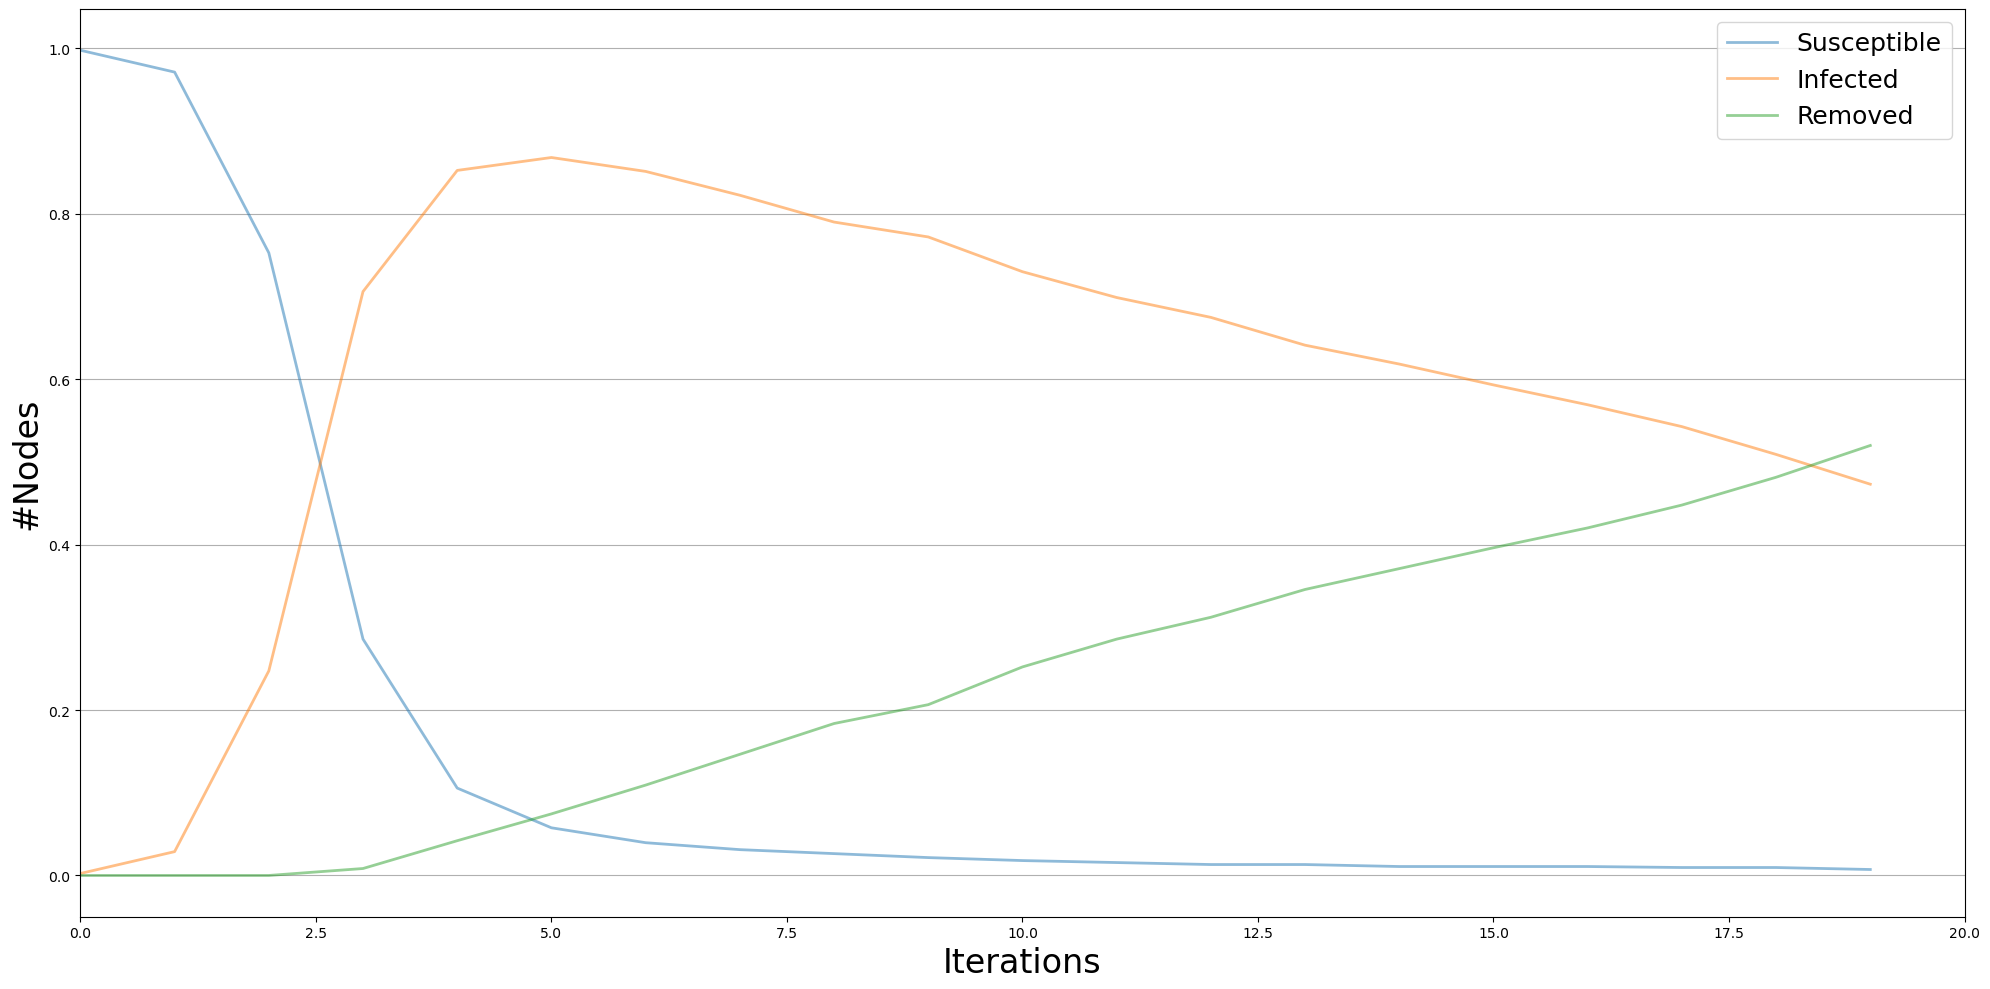

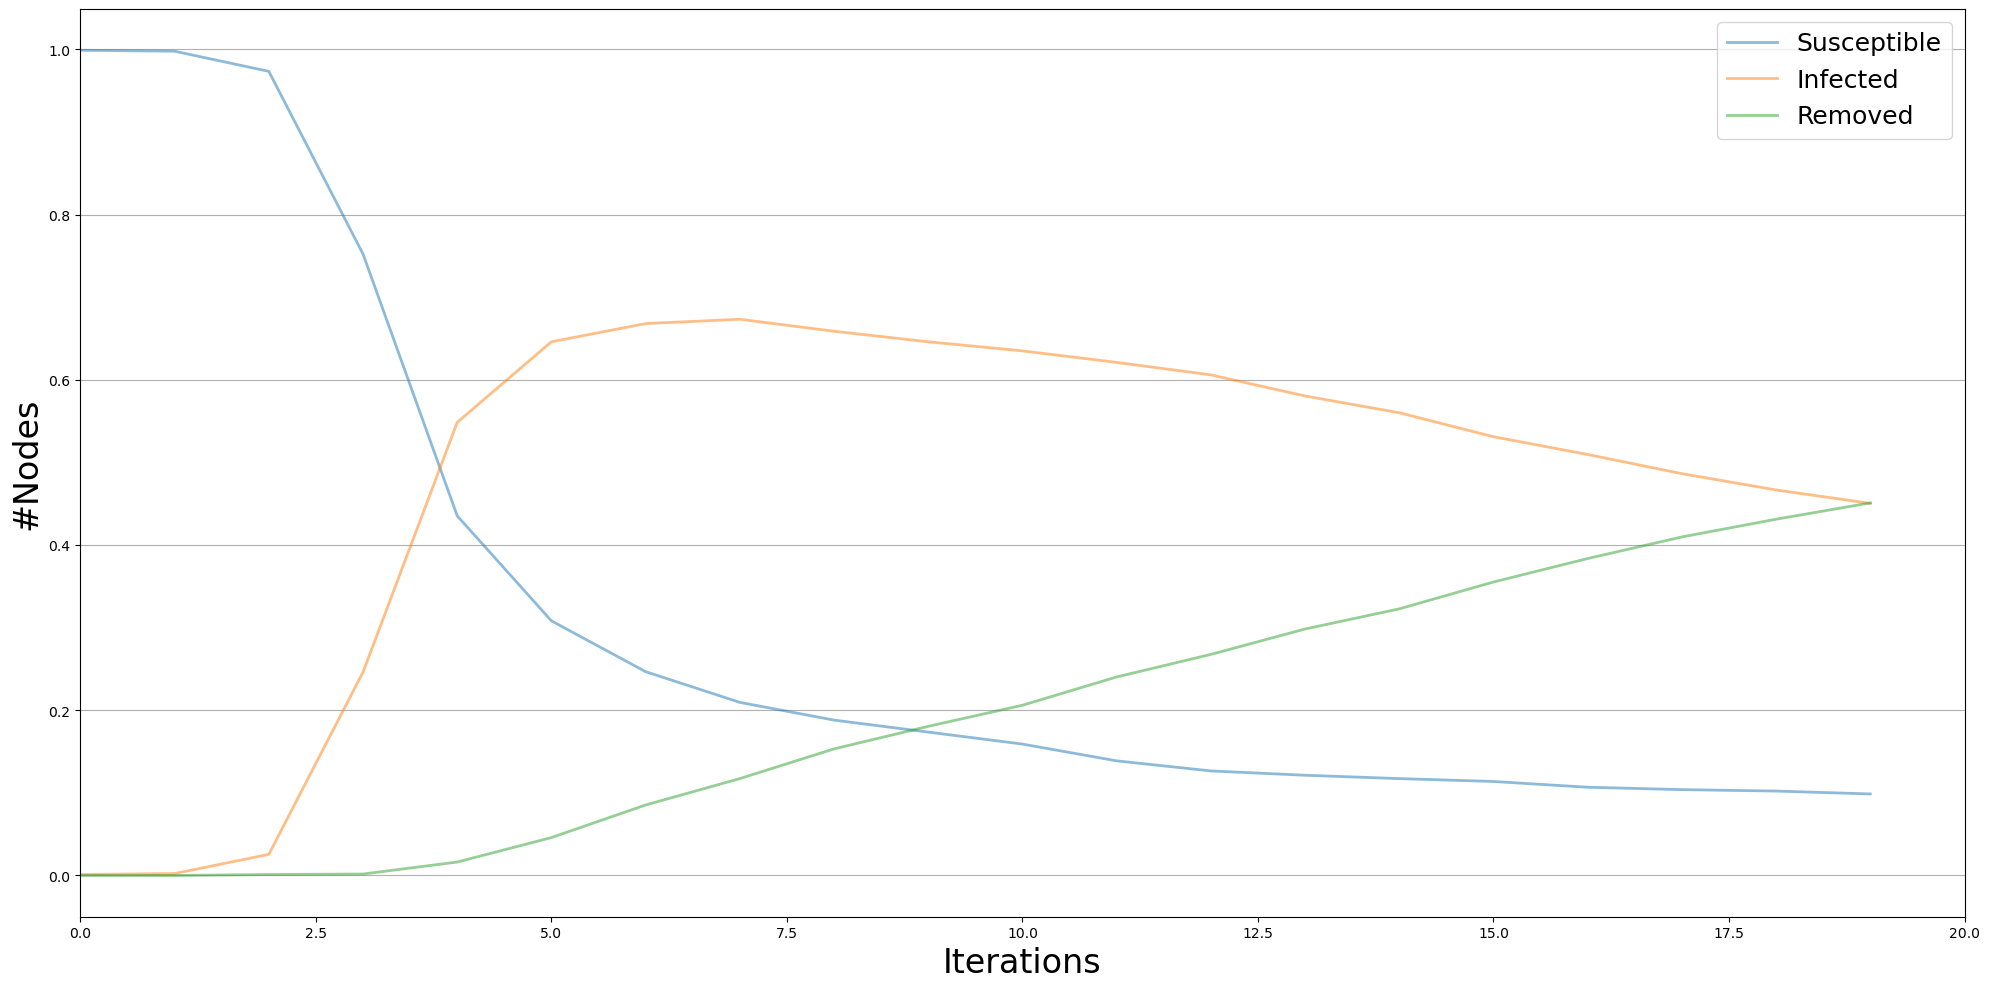

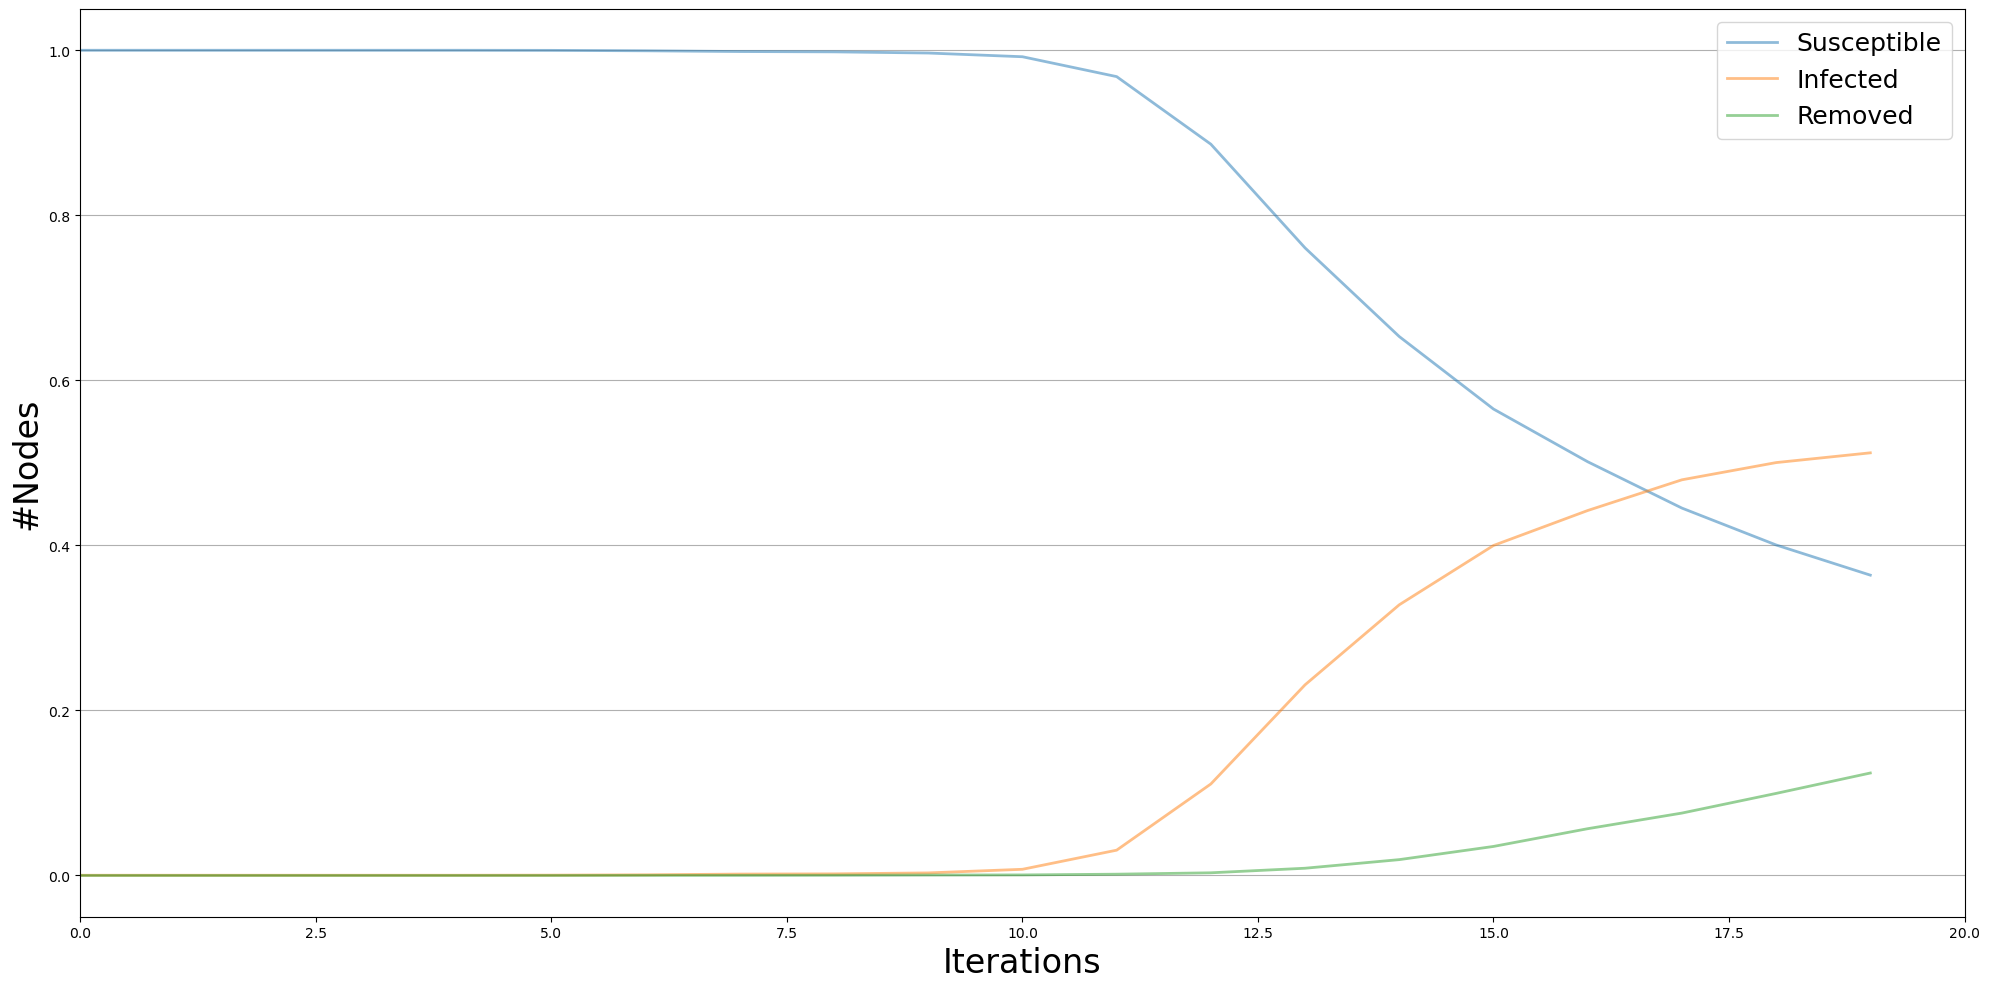

In [192]:
def run_diffusion(G, name, initial_trolls, beta=0.1, gamma=0.05):
    model = ep.SIRModel(G)
    config = mc.Configuration()
    config.add_model_parameter('beta', beta)
    config.add_model_parameter('gamma', gamma)
    config.add_model_initial_configuration('Infected', initial_trolls)
    
    model.set_initial_status(config)
    iterations = model.iteration_bunch(20)
    trends = model.build_trends(iterations)
    
    viz = DiffusionTrend(model, trends)
    viz.plot()
    

for name, G in components.items():
    e1, e2 = selected[name]
    run_diffusion(G, name, initial_trolls=[e1,e2], beta=0.1)

In [191]:
def get_priority_nodes(G, troll_editors, top_n=10):
    neighbors_1 = set(G.neighbors(troll_editors[0]))
    neighbors_2 = set(G.neighbors(troll_editors[1]))

    common = neighbors_1 & neighbors_2
    union_neighbors = neighbors_1 | neighbors_2

    priority = []
    for node in union_neighbors:
        score = G.degree(node)
        if node in common:
            score += 10
        priority.append((node, score))
    
    priority = sorted(priority, key=lambda x: x[1], reverse=True)

    print(f"Troll neighbors(union): {len(union_neighbors)}")
    print(f"Common neighbors: {len(common)}")
    print(f"Top {top_n} to check:")
    print(priority[:top_n])
    print()

    return priority[:top_n]

for name, G in components.items():
    e1, e2 = selected[name]
    get_priority_nodes(G, [e1, e2])

Troll neighbors(union): 190
Common neighbors: 6
Top 10 to check:
[('Rschen7754', 458), ('ArthurPSmith', 423), ('Ymblanter', 418), ('TomT0m', 384), ('Stryn', 383), ('GZWDer', 364), ('JAn Dudík', 362), ('ChristianKl', 356), ('Pasleim', 353), ('Jklamo', 352)]

Troll neighbors(union): 25
Common neighbors: 0
Top 10 to check:
[('Ajraddatz', 660), ('Rschen7754', 571), ('Jasper Deng', 527), ('Stryn', 505), ('Jianhui67', 479), ('Matěj Suchánek', 436), ('Jura1', 416), ('Wagino 20100516', 415), ('Vogone', 363), ('MisterSynergy', 334)]

Troll neighbors(union): 2
Common neighbors: 0
Top 10 to check:
[('Mahir256', 219), ('Karalainza', 80)]



#### Brief Summary
- The foundation can assess the plausibility of non-propagation by examing shortest path distances, common neighbors, and network density. In dense networks with short distances (≤2), propagation is almost certain, whereas in sparse networks with greater distances (≥4) and no common neighbors, it is plaussible that trolling has not yet spread.

- The priority list for checking editors should include immediate neighbors of confirmed trolls, ranked by their degree and whether they are common neighbors to both source. High-degree "hub" editors and those exposed to multiple independent trolling sources should be checked first to prevent catatrophic cascading effects across the community.